### **CC57 - MACHINE LEARNING - PREPROCESAMIENTO DE DATOS**

**Nombres / Apellidos:**
Rody Sebastian Vilchez Marin

**Código:**
u202216562

---

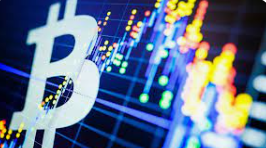

El dataset global de criptomonedas es un conjunto de datos completo  que ofrece una gran cantidad de información sobre más de 7500 criptomonedas, cada una de ellas combinada con el dólar estadounidense (USD). Este conjunto de datos es un recurso invaluable para cualquier persona interesada en explorar el mundo de las monedas digitales y analizar su comportamiento en el mercado. Estos no solo incluyen monedas populares como BTC, ETH y SOL, sino que también capturan monedas recién lanzadas.

**Estructura del Dataset**

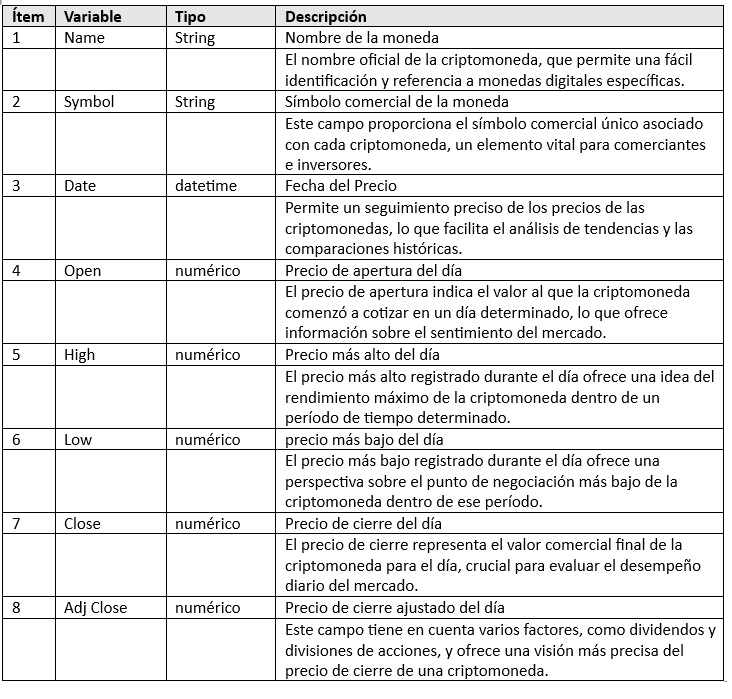

## Desarrollo

### 1) Cargar los datos

In [100]:
!file 01-Ejercicio-Preprocesamiento.zip

01-Ejercicio-Preprocesamiento.zip: cannot open `01-Ejercicio-Preprocesamiento.zip' (No such file or directory)


In [101]:
!unzip 01-Ejercicio-Preprocesamiento.zip

unzip:  cannot find or open 01-Ejercicio-Preprocesamiento.zip, 01-Ejercicio-Preprocesamiento.zip.zip or 01-Ejercicio-Preprocesamiento.zip.ZIP.


Reparar el comprimido en caso hubiera error durante la carga y descomprimir

In [102]:
# !zip -FF 01-Ejercicio-Preprocesamiento.zip --out fixed.zip
# !unzip fixed.zip -A

In [103]:
!which pip

/home/rosewt-dell/Documentos/GitHub/ML-Island/.conda/bin/pip


In [104]:
# !pip install pandas matplotlib seaborn 
# !pip install matplotlib_venn


### Carga de datos al cuaderno

In [105]:
import os

relative_data_path = "Ejercicio-Preprocesamiento/data/"
# listar todos los csv del folder path
csv_files = [f for f in os.listdir(relative_data_path) if f.endswith('.csv')]
csv_files.__len__()

7537

In [106]:
import pandas as pd
# revisar la metadata
df_metadata = pd.read_csv("Ejercicio-Preprocesamiento/metadata.csv")
df_metadata.head()

,Coin Pair Name,Coin Pair Symbol,File Path
0,Bitcoin USD,BTC-USD,BTC-USD.csv
1,Ethereum USD,ETH-USD,ETH-USD.csv
2,Tether USDt USD,USDT-USD,USDT-USD.csv
3,BNB USD,BNB-USD,BNB-USD.csv
4,USD Coin USD,USDC-USD,USDC-USD.csv


Se realizo la carga de metadatos y lectura de archivos sin problemas
- Se procedera a preprocesar la metadata antes de continuar con la carga de archivos 

## 2) Datos faltantes y duplicados


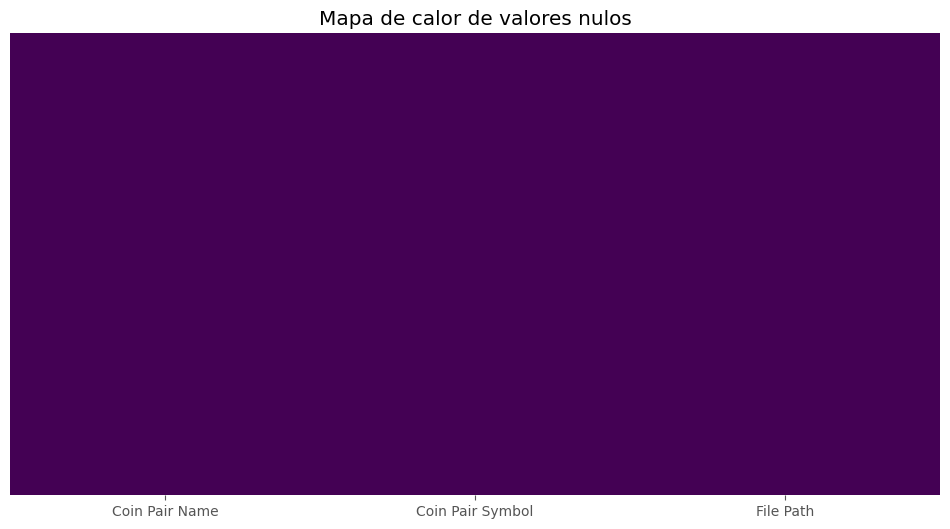

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
sns.heatmap(df_metadata.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de calor de valores nulos')
plt.show()


In [108]:
def verificar_archivos_perdidos(df_metadata, data_files):
  if len(data_files) == df_metadata.shape[0]:
    print("Los archivos coinciden con la metadata")
  else:
    print("Los archivos no coinciden con la metadata")
    print(f"{df_metadata.shape[0] - len(data_files)} archivos faltantes con respecto a la metadata")

verificar_archivos_perdidos(df_metadata, csv_files)

Los archivos no coinciden con la metadata
3766 archivos faltantes con respecto a la metadata


### 2.1 Datos faltantes

La metadata no es consistente con los data asociada, se realizara una exploracion para determinar la causa


In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

metadata_files = set(df_metadata['File Path'])
directory_files = set(csv_files)

faltan_en_directorio = metadata_files - directory_files
sobran_en_directorio = directory_files - metadata_files

print("Faltan en directorio:", len(faltan_en_directorio))
print("Sobran en directorio:", len(sobran_en_directorio))


Faltan en directorio: 0
Sobran en directorio: 0


2.1 Parece que no faltan datos, se atribuye a que el set solo toma una unica incidencia.

**Criterio:** Mayor cantidad de registros en metadata, al comparar registros unicos no se muestran diferencias.

**Se determina:** Duplicados en metadata

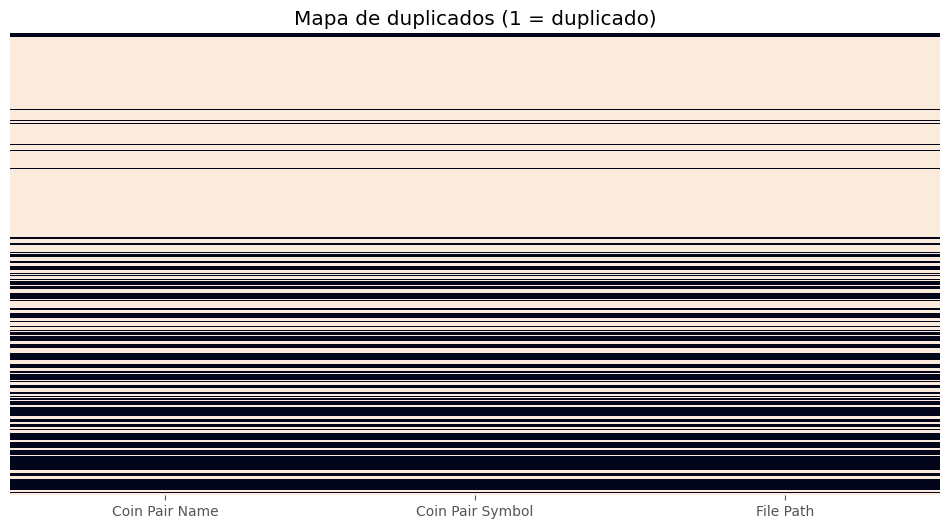

In [110]:
# Crear una máscara booleana para duplicados
duplicados = df_metadata.duplicated(keep=False)
# Expandir eso al DataFrame
binary_mask = pd.DataFrame(
    np.tile(duplicados.values[:, None], (1, df_metadata.shape[1])),
    columns=df_metadata.columns
)

plt.figure(figsize=(12, 6))
sns.heatmap(binary_mask, cmap='rocket', cbar=False, yticklabels=False)
plt.title('Mapa de duplicados (1 = duplicado)')
plt.show()


Se verifican duplicados.

In [111]:
def verificar_archivos_perdidos(df_metadata, data_files, duplicados):
  n_datos_metadata_sin_duplicados = df_metadata.shape[0] - duplicados
  if len(data_files) == n_datos_metadata_sin_duplicados:
    print("Los archivos coinciden con la metadata")
    print(f"Se cuenta con {len(data_files)} archivos")
  else:
    print("Los archivos no coinciden con la metadata")
    print(f"{n_datos_metadata_sin_duplicados - len(data_files)} archivos faltantes con respecto a la metadata sin duplicados")

duplicados_totales = int(df_metadata.duplicated().sum())
verificar_archivos_perdidos(df_metadata, csv_files, duplicados_totales)


Los archivos coinciden con la metadata
Se cuenta con 7537 archivos


In [112]:
# limpiar duplicados 
df_metadata = df_metadata.drop_duplicates(keep='first')
# verificar que no hay duplicados
duplicados_totales = int(df_metadata.duplicated().sum())
print(f"Duplicados totales: {duplicados_totales}")

Duplicados totales: 0


In [113]:
sns.color_palette('husl')

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.7350228985632719, 0.5952719904750953, 0.1944419133847522),
 (0.3126890019504329, 0.6928754610296064, 0.1923704830330379),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.23299120924703914, 0.639586552066035, 0.9260706093977744),
 (0.9082572436765556, 0.40195790729656516, 0.9576909250290225)]

/tmp/ipykernel_19717/4054280274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=etiquetas, y=valores, palette='pastel')


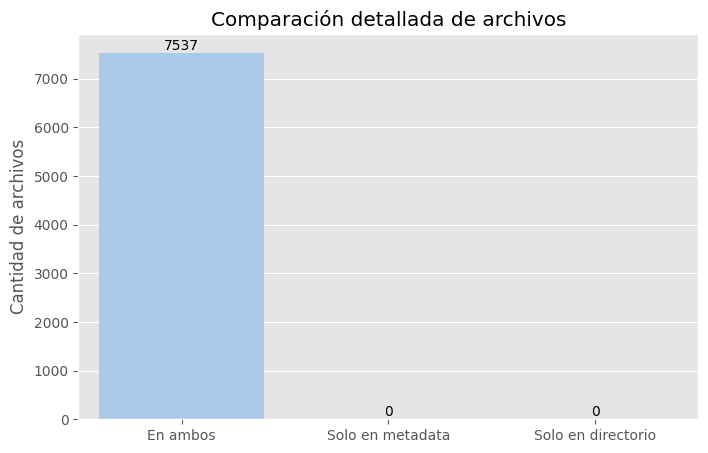

In [114]:
conteo = {
    'En ambos': len(metadata_files & directory_files),
    'Solo en metadata': len(faltan_en_directorio),
    'Solo en directorio': len(sobran_en_directorio)
}

valores = list(conteo.values())
etiquetas = list(conteo.keys())

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=etiquetas, y=valores, palette='pastel')
plt.title('Comparación detallada de archivos')
plt.ylabel('Cantidad de archivos')

# Agregar etiquetas encima de cada barra
for i, v in enumerate(valores):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.show()


In [115]:
# guardar
df_metadata.to_csv("Ejercicio-Preprocesamiento/clean_metadata.csv", index=False)

## EDA

In [116]:
df = pd.read_csv("Ejercicio-Preprocesamiento/clean_metadata.csv")
df.head()

,Coin Pair Name,Coin Pair Symbol,File Path
0,Bitcoin USD,BTC-USD,BTC-USD.csv
1,Ethereum USD,ETH-USD,ETH-USD.csv
2,Tether USDt USD,USDT-USD,USDT-USD.csv
3,BNB USD,BNB-USD,BNB-USD.csv
4,USD Coin USD,USDC-USD,USDC-USD.csv


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7537 entries, 0 to 7536
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Coin Pair Name    7537 non-null   object
 1   Coin Pair Symbol  7537 non-null   object
 2   File Path         7537 non-null   object
dtypes: object(3)
memory usage: 176.8+ KB


## Archivos individuales

In [118]:
import pandas as pd
import os

# Función para extraer información, con manejo de EmptyDataError
def extract_info(file_path):
    full_path = os.path.join(relative_data_path, file_path)
    try:
        df_file = pd.read_csv(full_path)
        return str(df_file.columns.tolist()), df_file.shape[0]
    except pd.errors.EmptyDataError:  # Captura el EmptyDataError
        print(f"El archivo {file_path} está vacío o no tiene encabezados.")
        return "[]", 0  # Devuelve lista vacía y 0 registros para archivos vacíos
    except Exception as e:
        return str(e), 0  # Manejo de otros errores


# Aplicar la función a cada fila usando apply()
df[['Headers', 'Registros']] = df['File Path'].apply(lambda x: pd.Series(extract_info(x)))

# Mostrar resultado
df.head()

,Coin Pair Name,Coin Pair Symbol,File Path,Headers,Registros
0,Bitcoin USD,BTC-USD,BTC-USD.csv,"['Name', 'Symbol', 'Date', 'Open', 'High', 'Lo...",3325
1,Ethereum USD,ETH-USD,ETH-USD.csv,"['Name', 'Symbol', 'Date', 'Open', 'High', 'Lo...",2176
2,Tether USDt USD,USDT-USD,USDT-USD.csv,"['Name', 'Symbol', 'Date', 'Open', 'High', 'Lo...",2176
3,BNB USD,BNB-USD,BNB-USD.csv,"['Name', 'Symbol', 'Date', 'Open', 'High', 'Lo...",2176
4,USD Coin USD,USDC-USD,USDC-USD.csv,"['Name', 'Symbol', 'Date', 'Open', 'High', 'Lo...",1843


In [119]:
# identificar cuantos valores distintos hay en los headers

print(f"{df['Headers'].unique().__len__()} encabezados unicos")

1 encabezados unicos


In [120]:
print(f"Se cuentan con : {int(df['Registros'].sum()):e} observaciones de diferentes criptos")

Se cuentan con : 5.351194e+06 observaciones de diferentes criptos


### Encontrar valores faltantes y duplicados en los registros de los archivos individuales

In [ ]:
def exist_duplicates_and_missing_values(file_path):
    full_path = os.path.join(relative_data_path, file_path)
    try:
        df_file = pd.read_csv(full_path)
        return bool(df_file.duplicated().any()), df_file.isnull().sum().sum()
    except pd.errors.EmptyDataError:  # Captura el EmptyDataError
        print(f"El archivo {file_path} está vacío o no tiene encabezados.")
        return False, 0  # Devuelve False y 0 para archivos vacíos
    except Exception as e:
        print(f"Error procesando el archivo {file_path}: {e}")
        return False, 0  # Manejo de otros errores

# Aplicar la función a cada fila usando apply()
df[['Duplicados', 'Nulos']] = df['File Path'].apply(
    lambda x: pd.Series(exist_duplicates_and_missing_values(x))
)

df.head()

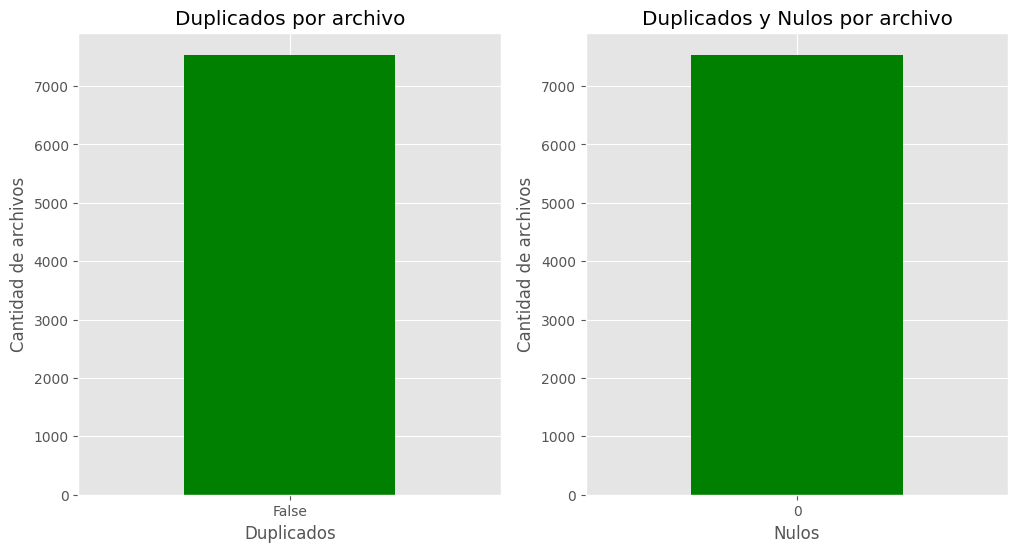

In [ ]:
plt.figure(figsize=(12, 6))
plt.style.use('ggplot')
plt.subplot(121)
df['Duplicados'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Duplicados por archivo')
plt.xlabel('Duplicados')
plt.ylabel('Cantidad de archivos')
plt.xticks(rotation=0)
plt.subplot(122)
df['Nulos'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Nulos por archivo')
plt.xlabel('Nulos')
plt.ylabel('Cantidad de archivos')
plt.xticks(rotation=0)
plt.title('Duplicados y Nulos por archivo')
plt.show()


In [ ]:
def get_data(file_path):
    full_path = os.path.join(relative_data_path, file_path)
    try:
        df_file = pd.read_csv(full_path)
        return df_file
    except pd.errors.EmptyDataError:  # Captura el EmptyDataError
        print(f"El archivo {file_path} está vacío o no tiene encabezados.")
        return pd.DataFrame()  # Devuelve False y 0 para archivos vacíos
    except Exception as e:
        print(f"Error procesando el archivo {file_path}: {e}")
        return pd.DataFrame()  # Devuelve False y 0 para archivos vacíos
    


# leer todos los archivos
dfs = []
for file in df['File Path']:
    df_file = get_data(file)
    if not df_file.empty:
        dfs.append(df_file)
# concatenar todos los archivos

Falta revisar si hay outliers, fechas de cierre

In [ ]:
# concatenar todos los archivos
df_all = pd.concat(dfs, ignore_index=True)
df_all.head()
df_all.info()
df_all.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5351194 entries, 0 to 5351193
Data columns (total 9 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Name       object 
 1   Symbol     object 
 2   Date       object 
 3   Open       float64
 4   High       float64
 5   Low        float64
 6   Close      float64
 7   Adj Close  float64
 8   Volume     int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 367.4+ MB


,Open,High,Low,Close,Adj Close,Volume
count,5.351194e+06,5.351194e+06,5.351194e+06,5.351194e+06,5.351194e+06,5.351194e+06
mean,2.590483e+02,7.963350e+02,2.105071e+02,2.556928e+02,2.556928e+02,1.063315e+08
std,5.460081e+04,5.335323e+05,1.795346e+04,5.419293e+04,5.419293e+04,6.973163e+10
min,0.000000e+00,0.000000e+00,-1.706356e+03,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.368000e-03,1.479000e-03,1.265000e-03,1.363000e-03,1.363000e-03,5.390000e+02
50%,1.866300e-02,1.999800e-02,1.738000e-02,1.859200e-02,1.859200e-02,3.685000e+04
75%,2.645629e-01,2.823820e-01,2.475905e-01,2.636520e-01,2.636520e-01,4.486428e+05
max,9.403425e+07,8.669533e+08,3.834883e+07,9.403425e+07,9.403425e+07,8.325207e+13


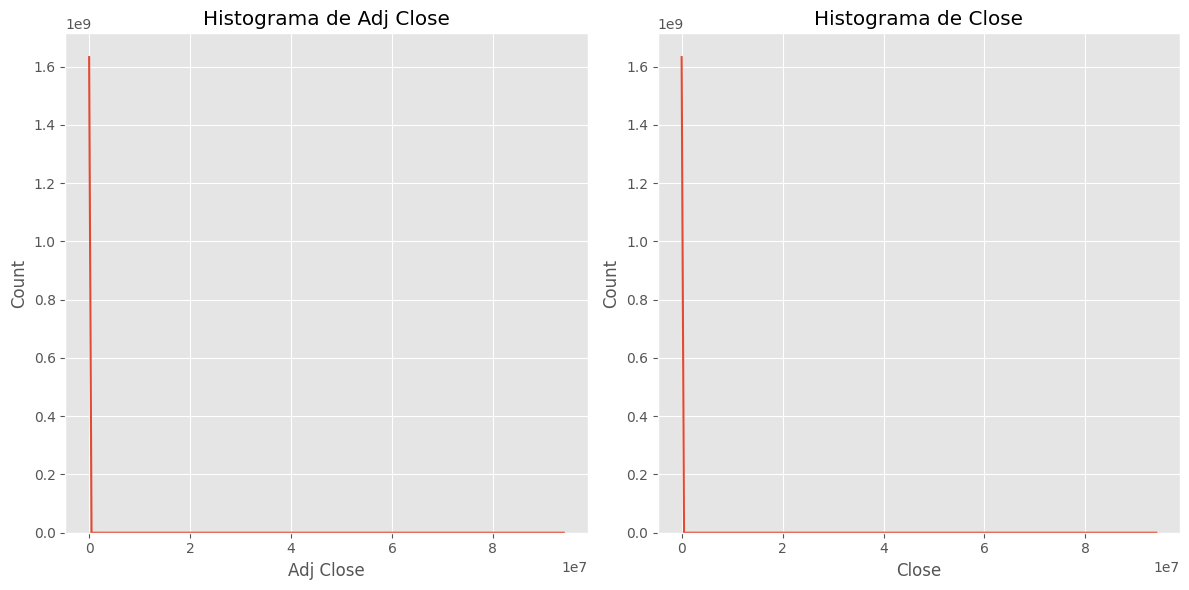

In [ ]:

# histogramas de las variables
plt.figure(figsize=(12, 6))
plt.subplot(121)
sns.histplot(df_all['Adj Close'], bins=50, kde=True)
plt.title('Histograma de Adj Close')
plt.subplot(122)
sns.histplot(df_all['Close'], bins=50, kde=True)
plt.title('Histograma de Close')
plt.tight_layout()
plt.show()

Estadísticas de la diferencia entre Adj Close y Close:
count    5351194.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
Name: Diferencia, dtype: float64


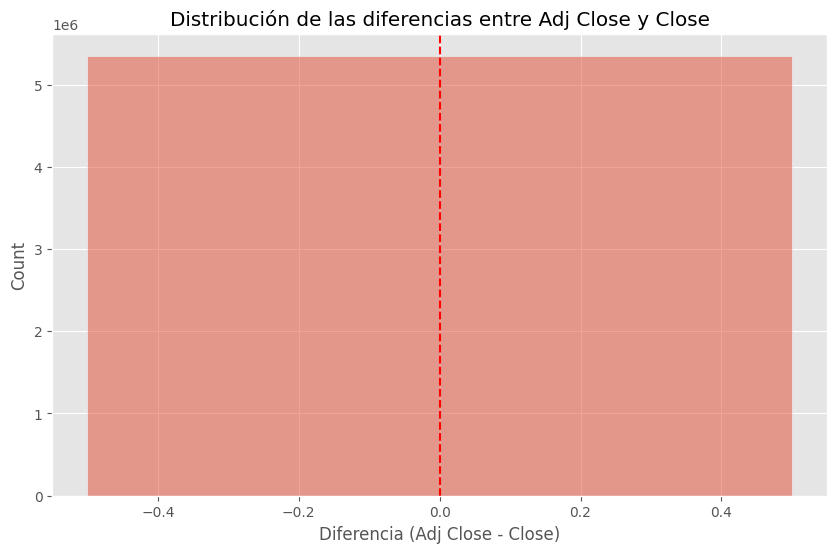

Prueba t: t-estadístico = nan, p-value = nan
La diferencia entre Adj Close y Close es estadísticamente no significativa


In [ ]:
# Calcular y visualizar la diferencia entre Adj Close y Close
df_all['Diferencia'] = df_all['Adj Close'] - df_all['Close']

# Estadísticas descriptivas de la diferencia
print("Estadísticas de la diferencia entre Adj Close y Close:")
print(df_all['Diferencia'].describe())

# Visualizar la distribución de las diferencias
plt.figure(figsize=(10, 6))
sns.histplot(df_all['Diferencia'], kde=True)
plt.title('Distribución de las diferencias entre Adj Close y Close')
plt.xlabel('Diferencia (Adj Close - Close)')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

# Prueba t para ver si la diferencia es estadísticamente significativa
# donde t-value es la diferencia entre las medias de los dos grupos y
# p-value es la probabilidad de que la diferencia sea debida al azar
from scipy import stats
t_stat, p_value = stats.ttest_1samp(df_all['Diferencia'], 0)
print(f"Prueba t: t-estadístico = {t_stat:.4f}, p-value = {p_value:.4f}")
print(f"La diferencia entre Adj Close y Close es estadísticamente {'significativa' if p_value < 0.05 else 'no significativa'}")

No solo no tiene diferencias estadisticamente significativas, no hay diferencia alguna. Tiene sentido ya que las criptomonedas no generan dividendos. Elminaremos el ajustado


In [ ]:
df_all = df_all.drop(columns=['Adj Close', 'Diferencia'])

In [ ]:
df_all.describe()

,Open,High,Low,Close,Volume
count,5.351194e+06,5.351194e+06,5.351194e+06,5.351194e+06,5.351194e+06
mean,2.590483e+02,7.963350e+02,2.105071e+02,2.556928e+02,1.063315e+08
std,5.460081e+04,5.335323e+05,1.795346e+04,5.419293e+04,6.973163e+10
min,0.000000e+00,0.000000e+00,-1.706356e+03,0.000000e+00,0.000000e+00
25%,1.368000e-03,1.479000e-03,1.265000e-03,1.363000e-03,5.390000e+02
50%,1.866300e-02,1.999800e-02,1.738000e-02,1.859200e-02,3.685000e+04
75%,2.645629e-01,2.823820e-01,2.475905e-01,2.636520e-01,4.486428e+05
max,9.403425e+07,8.669533e+08,3.834883e+07,9.403425e+07,8.325207e+13


In [ ]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5351194 entries, 0 to 5351193
Data columns (total 8 columns):
 #   Column  Dtype  
---  ------  -----  
 0   Name    object 
 1   Symbol  object 
 2   Date    object 
 3   Open    float64
 4   High    float64
 5   Low     float64
 6   Close   float64
 7   Volume  int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 326.6+ MB


In [ ]:
df_all.to_csv("Ejercicio-Preprocesamiento/clean_data.csv", index=False)
df_all = pd.read_csv("Ejercicio-Preprocesamiento/clean_data.csv")

Revisar, fechas inicio y cierre de cada cripto

In [ ]:
# fechas por cada criptomoneda
df_all['Date'] = pd.to_datetime(df_all['Date'])

# No deberias ser necesario, pero asegurarnos que no hay fechas duplicadas para cada criptomoneda
duplicados = df_all.duplicated(subset=['Date', 'Symbol'], keep=False)
duplicados_count = duplicados.sum()
duplicados_count

np.int64(0)

In [ ]:
# fecha mas reciente por criptomoneda
df_all['Date'] = pd.to_datetime(df_all['Date'])
df_all['Date'] = df_all['Date'].dt.date

fecha_resumen = df_all.groupby('Symbol')['Date'].agg(['max', 'min'])
fecha_resumen.columns = ['Fecha Min', 'Fecha Max']

# Resetear el índice para facilitar la unión
fecha_resumen = fecha_resumen.reset_index()

fecha_resumen.head()

# Unir la información de fechas con el DataFrame original
df_metadata = df_metadata.merge(fecha_resumen, left_on='Coin Pair Symbol', right_on='Symbol', how='left')


In [ ]:
df_metadata.head()

,Coin Pair Name,Coin Pair Symbol,File Path,Symbol,Fecha Min,Fecha Max
0,Bitcoin USD,BTC-USD,BTC-USD.csv,BTC-USD,2014-09-17,2023-10-24
1,Ethereum USD,ETH-USD,ETH-USD.csv,ETH-USD,2017-11-09,2023-10-24
2,Tether USDt USD,USDT-USD,USDT-USD.csv,USDT-USD,2017-11-09,2023-10-24
3,BNB USD,BNB-USD,BNB-USD.csv,BNB-USD,2017-11-09,2023-10-24
4,USD Coin USD,USDC-USD,USDC-USD.csv,USDC-USD,2018-10-08,2023-10-24


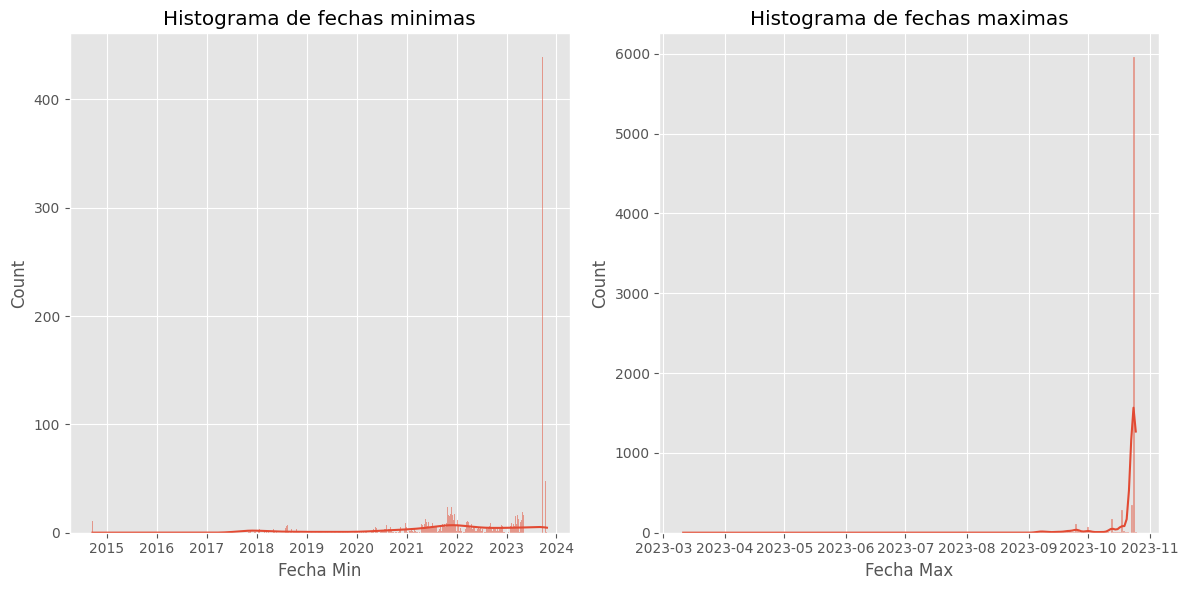

In [ ]:
# graficar las fechas minimas y maximas de cada criptomoneda
plt.figure(figsize=(12, 6))
plt.subplot(121)
sns.histplot(df_metadata['Fecha Min'], bins=50, kde=True)
plt.title('Histograma de fechas minimas')
plt.subplot(122)
sns.histplot(df_metadata['Fecha Max'], bins=50, kde=True)
plt.title('Histograma de fechas maximas')
plt.tight_layout()
plt.show()